In [2]:
Interesting_regions =   [4, 5, 32, 33, 44, 45, 48, 49]
Interesting_regions_right =   [5, 33, 45, 49]
Interesting_regions_left = [4, 32, 44, 48,]

Good_subjects =         [0, 2, 5, 9, 12, 14]
Ok_subjects =           [1, 3, 4, 6, 11, 13, 19]
Other_subjects = [i for i in range(20) if i not in Ok_subjects and i not in Good_subjects]

Subjects_dict = {"Good_subjects": Good_subjects, "Ok_subjects":Ok_subjects, "Other_subjects":Other_subjects}

data_folder="../Data/"


from BCI_Library import read_subject, plot_brain, train_models, extract_features_more_bands, saveresults_pickle, select_rows
from BCI_Library import sort_rank, compute_welch_select_regions, extract_features_from_spectra_more_bands,compute_welch
from BCI_Library import plot_hist2d_selected_regions_folds, select_regions_MyCriteria, select_regions_Cohen_effect_size

"""# new_row = {
#     "ROIs": [selected_regions_EEG],
#     "NROIs":[25]
#     "DataType": ["EEG"],
#     "freqs_band": [((4,8),(8,12),(12,30))],  
#     "subject": [subject_index],
#     "Classifier": ["LDA"],
#     "Performance": [training[0]],
#     "Features": ["PowerSpectra - MeanMax band"],
#     "Comments": ["-"],
#     "Regions Selection": ["-"]
#     "Date": [today],
#     "Personalized_Freq_Range" = False,
# }"""


2026-07-18 11:15:01.360342: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-18 11:15:01.439364: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-18 11:15:02.745988: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


'# new_row = {\n#     "ROIs": [selected_regions_EEG],\n#     "NROIs":[25]\n#     "DataType": ["EEG"],\n#     "freqs_band": [((4,8),(8,12),(12,30))],  \n#     "subject": [subject_index],\n#     "Classifier": ["LDA"],\n#     "Performance": [training[0]],\n#     "Features": ["PowerSpectra - MeanMax band"],\n#     "Comments": ["-"],\n#     "Regions Selection": ["-"]\n#     "Date": [today],\n#     "Personalized_Freq_Range" = False,\n# }'

# EEG investigate

In [3]:
import mne
import numpy as np
import h5py
from mne.time_frequency import psd_array_welch
import matplotlib.pyplot as plt

subject_index = 1

data_2_MI = read_subject(data_folder, "EEG", "MI",subject_index)
data_2_Rest = read_subject(data_folder, "EEG", "Baseline",subject_index)

# My frequency sampling
sfreq = 250

subject_1 trial_94 has wrong shape ((2,))
subject_1 trial_95 has wrong shape ((2,))
subject_1 trial_94 has wrong shape ((2,))
subject_1 trial_95 has wrong shape ((2,))


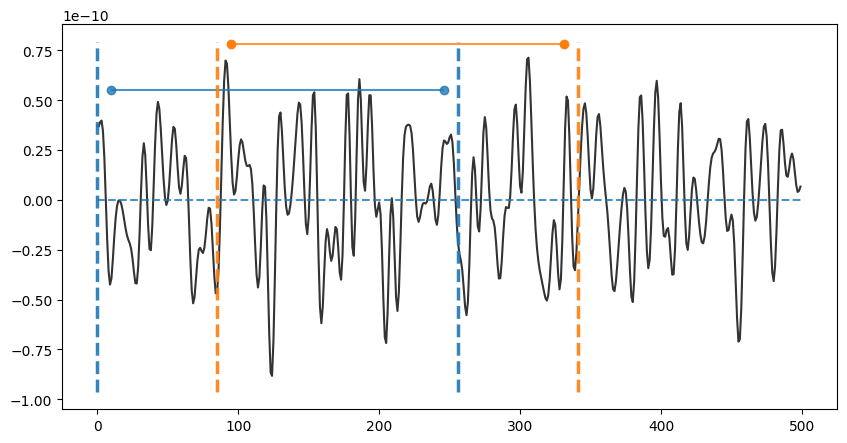

In [29]:
from scipy.signal import firwin, filtfilt
figname="../Images/Windowing_example.png"

signal = data_2_MI[1][19]
numtaps = 501
fs = 250 
fir = firwin(numtaps, [4, 35], pass_zero=False, fs=fs)
filtered = filtfilt(fir, 1.0,signal )

shift = 200
amplitude_tot = 500 

T = 256
shift = 85
hline_shift = 10
hls = hline_shift

fg,ax =plt.subplots(figsize=(10,5))
ax.plot(filtered[shift:amplitude_tot+shift],color="black",alpha=0.8)
ymin,ymax = np.array(ax.get_ylim())#*1.1
plt.hlines(0,0,amplitude_tot,linestyles="--", alpha = 0.8)

plt.vlines([0,T],ymin,ymax , linestyles="--", alpha = 0.9, linewidth=2.5)
plt.hlines(0.55*10**(-10),hls ,T-hls, alpha = 0.8)
plt.scatter([hls ,T-hls],[0.55*10**(-10)]*2, alpha = 0.8)

plt.vlines([0+shift,T+shift],ymin,ymax, linestyles="--", alpha = 0.9, color = "C1" , linewidth=2.5,zorder=4)
plt.hlines([0.78*10**(-10)],hls+shift,T-hls+shift, alpha = 0.8,color="C1")
plt.scatter([hls+shift ,T-hls+shift],[0.78*10**(-10)]*2,zorder=3,color="C1")


plt.savefig(figname, dpi=300, bbox_inches='tight')
# plt.vlines([0+2*shift,T+2*shift],ymin,ymax, linestyles="--", alpha = 0.9, color = "C2" , linewidth=2.5,zorder=4)
# plt.hlines([0.98*10**(-10)],hls+2*shift,T-hls+2*shift, alpha = 0.8,color="C2")
# plt.scatter([hls+2*shift ,T-hls+2*shift],[0.98*10**(-10)]*2,zorder=3,color="C2")

# Power spectra features - investigate EEG (or MEG)

In [12]:
import mne
import numpy as np
import h5py
from mne.time_frequency import psd_array_welch
import matplotlib.pyplot as plt

subject_index = 1

data_2_MI = read_subject(data_folder, "EEG", "MI",subject_index)
data_2_Rest = read_subject(data_folder, "EEG", "Baseline",subject_index)

# My frequency sampling
sfreq = 250

subject_1 trial_94 has wrong shape ((2,))
subject_1 trial_95 has wrong shape ((2,))
subject_1 trial_94 has wrong shape ((2,))
subject_1 trial_95 has wrong shape ((2,))


In [13]:
# power spectra with WELCH metod

#(fmin=0, fmax=inf, n_fft=256, 
# n_overlap, n_per_seg, n_fft,
#  window)

fmin=4
fmax=30
n_per_seg = 250             # window to do power spectra
n_fft = n_per_seg + 50      # for the FFT I consider a padding of 0 at the edges, if n_per_seg + 50 it is 25 samples per side
n_overlap = n_per_seg//2

stime = 1 * sfreq
etime = 1 * sfreq

kargs = {"sfreq":sfreq, "fmin":fmin, "fmax":fmax,
        "n_per_seg":n_per_seg, "n_fft":n_fft,
        "n_overlap":n_overlap}

wpsdMI, frequiMI = psd_array_welch(data_2_MI[:,:,stime:-etime], **kargs )
wpsdRest, frequiRest = psd_array_welch(data_2_Rest[:,:,stime:-etime], **kargs )
wpsdRest.shape


Effective window size : 1.200 (s)
Effective window size : 1.200 (s)


(94, 68, 32)

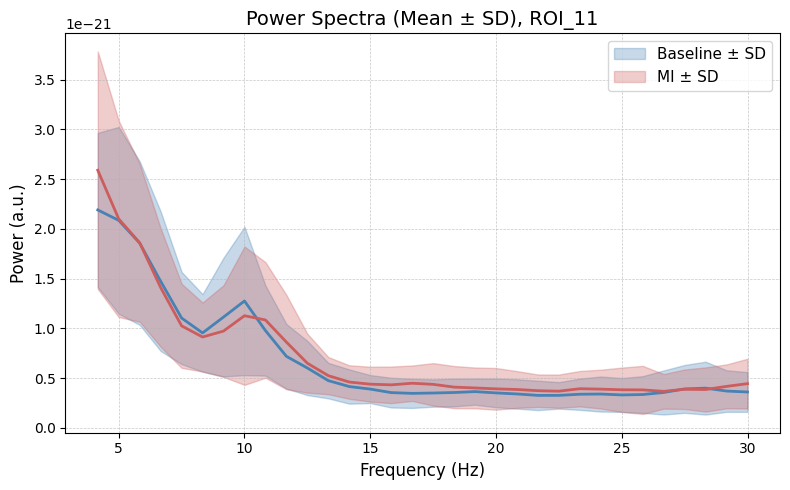

[4, 5, 32, 33, 44, 45, 48, 49]

In [14]:
# some plot


def plot_spectra(wpsdMI_1ROI,wpsdRest_1ROI,ROI=None):

    wpsd_MI_std = wpsdMI_1ROI.std(axis=0)
    wpsd_MI_mean = wpsdMI_1ROI.mean(axis=0)

    wpsd_Rest_std = wpsdRest_1ROI.std(axis=0)
    wpsd_Rest_mean = wpsdRest_1ROI.mean(axis=0)

    plt.figure(figsize=(8,5))

    plt.fill_between(
        frequiRest, 
        wpsd_Rest_mean - wpsd_Rest_std, 
        wpsd_Rest_mean + wpsd_Rest_std,
        color="steelblue", alpha=0.3, label="Baseline ± SD"
    )
    plt.plot(frequiRest, wpsd_Rest_mean, color="steelblue", linewidth=2)

    plt.fill_between(
        frequiMI, 
        wpsd_MI_mean - wpsd_MI_std, 
        wpsd_MI_mean + wpsd_MI_std,
        color="indianred", alpha=0.3, label="MI ± SD"
    )
    plt.plot(frequiMI, wpsd_MI_mean, color="indianred", linewidth=2)


    plt.title(f"Power Spectra (Mean ± SD), ROI_{ROI}", fontsize=14)
    plt.xlabel("Frequency (Hz)", fontsize=12)
    plt.ylabel("Power (a.u.)", fontsize=12)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
    ylims = plt.ylim()
    #plt.vlines((4,8,12,30),0, ylims[1],linestyles="--",color="navy",alpha=.8)
    plt.ylim(ylims)
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()


for ROI in [11]:
    wpsdMI_1ROI =wpsdMI[:,ROI,:]
    wpsdRest_1ROI =wpsdRest[:,ROI,:] 
    #plot_spectra(wpsdMI_1ROI[index_per_fold[0][0:72]],wpsdRest_1ROI[index_per_fold[0][72:]-90],ROI)
    plot_spectra(wpsdMI_1ROI, wpsdRest_1ROI, ROI)

[4, 5, 32, 33, 44, 45, 48, 49]

### other

In [32]:
# selecting the ROIs where the difference between MI and Rest is max 

i_freq_max_rest=[] # indici delle frequenze di dove é il massimo
i_freq_max_diff=[] # .... where i find the max of diff
max_rest=[]
max_diff_perc=[] # max of the difference reported in percentage, not the maximum of the percentage difference

for roi in range(68):
    wpsdMI_1ROI =wpsdMI[:,roi,:]
    wpsdRest_1ROI =wpsdRest[:,roi,:]
    wpsd_MI_mean = wpsdMI_1ROI.mean(axis=0)
    wpsd_Rest_mean = wpsdRest_1ROI.mean(axis=0)
    
    max_rest.append(np.max(wpsd_Rest_mean))
    # non lax rest, ma rest in quel bin
    max_diff_perc.append(np.max(wpsd_Rest_mean-wpsd_MI_mean)/max_rest[-1])

    i_freq_max_rest.append(np.argmax(wpsd_Rest_mean))
    i_freq_max_diff.append(np.argmax(wpsd_Rest_mean-wpsd_MI_mean))

i_freq_max_diff=np.array(i_freq_max_diff)
np.argsort(max_diff_perc) # from smaller to bigger

array([56, 57, 10,  5, 18, 29, 52,  3, 53, 54, 48, 55, 38, 36, 40,  2, 39,
       28, 64,  4, 60, 24, 25, 33, 11, 44, 49, 37, 63, 41, 65, 19, 31, 45,
       35, 46,  8, 16, 13, 14, 12,  9, 66,  0, 15, 22, 58, 47, 34, 23, 30,
        6, 27, 62, 20, 21, 50,  7, 32, 26,  1, 17, 51, 42, 59, 43, 61, 67])

In [33]:
# I choose the nregions where I have the greatest difference between MI and Rest 
# (but being careful to include the Interesting_regions)
nregions = 34 
selected_regions = [i for i in Interesting_regions]
for i in range(68):
    if np.argsort(max_diff_perc)[-i-1] not in selected_regions:
        selected_regions.append(int(np.argsort(max_diff_perc)[-i-1]))
    if len(selected_regions) >= nregions:
        break
    

array([10.        , 10.83333333, 11.66666667])

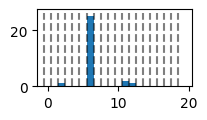

In [34]:
plt.figure(figsize=(2,1)) 
plt.hist(i_freq_max_diff[selected_regions],bins=np.array([i for i in range(20)])+0.5)
plt.vlines([i-0.5 for i in range(20)],*plt.ylim(), colors="black", linestyles="--", alpha=0.5)
frequiMI[[6,7,8]]
# the maximum difference for subject 2 is found at freqs with indexes 6,7,8

In [35]:
frequiMI

array([ 5.        ,  5.83333333,  6.66666667,  7.5       ,  8.33333333,
        9.16666667, 10.        , 10.83333333, 11.66666667, 12.5       ,
       13.33333333, 14.16666667, 15.        , 15.83333333, 16.66666667,
       17.5       , 18.33333333, 19.16666667, 20.        , 20.83333333,
       21.66666667, 22.5       , 23.33333333, 24.16666667, 25.        ,
       25.83333333, 26.66666667, 27.5       , 28.33333333, 29.16666667,
       30.        ])

In [36]:
min_freq_frature = 8
max_freq_feature = 14
start_freq_idx = np.where(frequiMI>=min_freq_frature)[0][0]
end_freq_idx = np.where(frequiMI<=max_freq_feature)[0][-1]

In [37]:
wpsdRest_ROIs_freqs = wpsdRest[:,selected_regions,start_freq_idx:end_freq_idx]
wpsdMI_ROIs_freqs = wpsdMI[:,selected_regions,start_freq_idx:end_freq_idx]
wpsdRest_ROIs_freqs.shape

(94, 34, 6)

In [40]:
# as features i chose the max and the maen of selected_ROIs in freqs 8.3 to 13.3
features_MI = np.concatenate((wpsdMI_ROIs_freqs.mean(axis=-1,keepdims=True),
                              wpsdMI_ROIs_freqs.max(axis=-1,keepdims=True)),
                              axis=-1)
print(features_MI.shape)
features_MI = features_MI.reshape(94,-1)

features_Rest = np.concatenate((wpsdRest_ROIs_freqs.mean(axis=-1,keepdims=True),
                              wpsdRest_ROIs_freqs.max(axis=-1,keepdims=True)),
                              axis=-1)
features_Rest = features_Rest.reshape(94,-1)

features_MI.reshape(94,-1).shape
# for each trial i have mean and max of each ROI: 2 features for each of the 34 ROI:
# for each trial i have 68 features (both for Rest and MI tasks)

(94, 34, 2)


(94, 68)

In [41]:
features = np.concatenate((features_Rest,features_MI),axis=0)
labels = np.array([0 for i in range (94)] + [1 for i in range (94)]) # 0 for Rest, 1 for MI
features.shape


(188, 68)

In [42]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix

kf = KFold(n_splits=5, shuffle=True, random_state=264)

fold_accuracies = []
fold_confusions = []

for fold_idx, (train_idx, val_idx) in enumerate(kf.split(features)):
    print(f"\n----- Fold {fold_idx+1} -----")

    X_train, X_val = features[train_idx], features[val_idx]
    y_train, y_val = labels[train_idx], labels[val_idx]

    # StandardScaler:
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled   = scaler.transform(X_val)

    # LDA
    lda = LinearDiscriminantAnalysis()
    lda.fit(X_train_scaled, y_train)

    # Predict on validation
    y_pred = lda.predict(X_val_scaled)

    # Accuracy
    acc = accuracy_score(y_val, y_pred)
    fold_accuracies.append(acc)

    # Confusion matrix
    cm = confusion_matrix(y_val, y_pred)
    fold_confusions.append(cm)

    print(f"Fold {fold_idx+1} accuracy: {acc:.4f}, Confusion matrix:")
    print(cm)

# Summary
print("==================================")
print("Mean accuracy:", np.mean(fold_accuracies))
print("Std accuracy:", np.std(fold_accuracies))




----- Fold 1 -----
Fold 1 accuracy: 0.6579, Confusion matrix:
[[14  6]
 [ 7 11]]

----- Fold 2 -----
Fold 2 accuracy: 0.4737, Confusion matrix:
[[ 6  7]
 [13 12]]

----- Fold 3 -----
Fold 3 accuracy: 0.6053, Confusion matrix:
[[13  9]
 [ 6 10]]

----- Fold 4 -----
Fold 4 accuracy: 0.4865, Confusion matrix:
[[10  7]
 [12  8]]

----- Fold 5 -----
Fold 5 accuracy: 0.7027, Confusion matrix:
[[12 10]
 [ 1 14]]
Mean accuracy: 0.5852062588904694
Std accuracy: 0.09129520148172625


# Power spectra features -  Integrate MEG EEG

In [2]:
import mne
import numpy as np
import h5py
from mne.time_frequency import psd_array_welch
import matplotlib.pyplot as plt
subject_index=2

print(f"\n\n Subject {subject_index}")

data_2_MI_EEG  = read_subject(data_folder, "EEG", "MI",subject_index)
data_2_Rest_EEG = read_subject(data_folder, "EEG", "Baseline",subject_index)

data_2_MI_MEG  = read_subject(data_folder, "MEG", "MI",subject_index)
data_2_Rest_MEG = read_subject(data_folder, "MEG", "Baseline",subject_index)

# My frequency sampling
sfreq = 250



 Subject 2


In [ ]:
fmin=3
fmax=30
n_per_seg = 250             # window to do power spectra
n_fft = n_per_seg + 50      # for the FFT I consider a padding of 0 at the edges, of 25 samples per side
n_overlap = n_per_seg//2

# miff = 8
# maff = 14
nbs=30

stime = 1 * sfreq
etime = 1 * sfreq

kargs = {"sfreq":sfreq, "fmin":fmin, "fmax":fmax,
        "n_per_seg":n_per_seg, "n_fft":n_fft,
        "n_overlap":n_overlap}

#  return features_MI, features_Rest, labels_MI, labels_Rest, selected_regions
Feat_extraction_EEG = extract_features_more_bands(data_2_MI_EEG, data_2_Rest_EEG, 
                                sfreq, starttime=stime, endtime=etime,
                                #min_freq_frature=miff, max_freq_frature=maff, 
                                nbest_regions=nbs, kargs_welch=kargs)

Feat_MI_EEG, Feat_Rest_EEG, labls_MI_EEG, labls_Rest_EEG, selected_regions_EEG = Feat_extraction_EEG

Feat_extraction_MEG = extract_features_more_bands(data_2_MI_MEG, data_2_Rest_MEG,
                                sfreq, starttime=stime, endtime=etime,
                                #min_freq_frature=miff, max_freq_frature=maff, 
                                nbest_regions=nbs, kargs_welch=kargs)

Feat_MI_MEG,Feat_Rest_MEG, labls_MI_MEG,labls_Rest_MEG, selected_regions_MEG = Feat_extraction_MEG

Effective window size : 1.200 (s)
Effective window size : 1.200 (s)
Effective window size : 1.200 (s)
Effective window size : 1.200 (s)


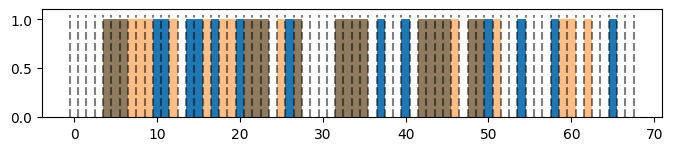

In [8]:
# see which regions have been chosen
plt.figure(figsize=(8,1.4)) 
a,b,c = plt.hist(selected_regions_EEG, bins=[i-0.5 for i in range(69)])
a,b,c = plt.hist(selected_regions_MEG, bins=[i-0.5 for i in range(69)],alpha=0.5)
plt.vlines([i-0.5 for i in range(69)],*plt.ylim(), colors="black", linestyles="--", alpha=0.5)

In [9]:
all_selected_ROIs = [i for i in selected_regions_EEG if i not in selected_regions_MEG]
all_selected_ROIs = all_selected_ROIs + [i for i in selected_regions_MEG]
#all_selected_ROIs = [i for i in selected_regions_EEG if i in selected_regions_MEG]

Both_color = "orange"; EEG_color = "red"; MEG_color = "yellow"
colors = [
    Both_color if (i in selected_regions_MEG and i in selected_regions_EEG)
    else MEG_color if i in selected_regions_MEG
    else EEG_color
    for i in all_selected_ROIs
]


In [15]:
plot_brain(all_selected_ROIs, brain_object_dict={"title":"EEG","hemi": "both"}, colors=colors)

Using pyvistaqt 3d backend.
Reading labels from parcellation...
   read 35 labels from /Users/giovanni.messuti/mne_data/MNE-sample-data/subjects/fsaverage/label/lh.aparc.annot
   read 34 labels from /Users/giovanni.messuti/mne_data/MNE-sample-data/subjects/fsaverage/label/rh.aparc.annot


In [12]:
Features_MI = np.concatenate((Feat_MI_EEG,Feat_MI_MEG), axis=1)
Features_Rest = np.concatenate((Feat_Rest_EEG,Feat_Rest_MEG), axis=1)
Features = np.concatenate((Features_MI,Features_Rest),axis=0)
Labels = np.concatenate((labls_MI_EEG,labls_Rest_EEG))
Feat_MI_MEG.shape, Features_MI.shape, Features.shape, labls_MI_EEG.shape, Labels.shape

((96, 180), (96, 360), (192, 360), (96,), (192,))

In [18]:
from sklearn.svm import SVC 
from sklearn.ensemble import RandomForestClassifier
training = train_models(Features,Labels,
                        method=RandomForestClassifier, 
                        seed=537, verbose=True)



----- Fold 1 -----
Fold 1 accuracy: 0.8718, Confusion matrix:
[[18  3]
 [ 2 16]]

----- Fold 2 -----
Fold 2 accuracy: 0.8974, Confusion matrix:
[[19  2]
 [ 2 16]]

----- Fold 3 -----
Fold 3 accuracy: 0.8947, Confusion matrix:
[[15  2]
 [ 2 19]]

----- Fold 4 -----
Fold 4 accuracy: 0.9737, Confusion matrix:
[[16  1]
 [ 0 21]]

----- Fold 5 -----
Fold 5 accuracy: 0.9211, Confusion matrix:
[[19  1]
 [ 2 16]]

Mean accuracy: 0.9117408906882591
Std accuracy: 0.034678922464716114


Mean accuracy: 0.9117408906882591
Std accuracy: 0.034678922464716114

In [ ]:
print(f"\n\n Subject {subject_index}")
data_2_MI_EEG = read_subject(data_folder, "EEG", "MI",subject_index, verbose=False)
data_2_Rest_EEG =read_subject(data_folder, "EEG", "Baseline",subject_index, verbose=False)
data_2_MI_MEG = read_subject(data_folder, "MEG", "MI",subject_index, verbose=False)
data_2_Rest_MEG =read_subject(data_folder, "MEG", "Baseline",subject_index, verbose=False)
#####################################################################################################################
fmin=3
fmax=30
n_per_seg = 250             # window to do power spectra
n_fft = n_per_seg + 50      # for the FFT I consider a padding of 0 at the edges, of 25 samples per side
n_overlap = n_per_seg//2

stime = 1 * sfreq
etime = 1 * sfreq

kargs = {"sfreq":sfreq, "fmin":fmin, "fmax":fmax,
        "n_per_seg":n_per_seg, "n_fft":n_fft,
        "n_overlap":n_overlap}

#  return features_MI, features_Rest, labels_MI, labels_Rest, selected_regions
Feat_extraction_EEG = extract_features_more_bands(data_2_MI_EEG, data_2_Rest_EEG, 
                                sfreq, starttime=stime, endtime=etime,
                                #min_freq_frature=miff, max_freq_frature=maff, 
                                nbest_regions=nbs, kargs_welch=kargs)

Feat_MI_EEG, Feat_Rest_EEG, labls_MI_EEG, labls_Rest_EEG, selected_regions_EEG = Feat_extraction_EEG

Feat_extraction_MEG = extract_features_more_bands(data_2_MI_MEG, data_2_Rest_MEG, 
                                sfreq, starttime=stime, endtime=etime,
                                #min_freq_frature=miff, max_freq_frature=maff, 
                                nbest_regions=nbs, kargs_welch=kargs)

Feat_MI_MEG, Feat_Rest_MEG, labls_MI_MEG, labls_Rest_MEG, selected_regions_MEG = Feat_extraction_MEG

Features_MI = np.concatenate((Feat_MI_EEG,Feat_MI_MEG), axis=1)
Features_Rest = np.concatenate((Feat_Rest_EEG,Feat_Rest_MEG), axis=1)
Features = np.concatenate((Features_MI,Features_Rest))
Labels = np.concatenate((labls_MI_EEG,labls_Rest_EEG))
#print(Feat_MI_MEG.shape, Features_MI.shape, Features.shape, labls_MI_EEG.shape, Labels.shape)
#####################################################################################################################

training = train_models(Features,Labels,
                        method=RandomForestClassifier, 
                        seed=537,verbose=True)



 Subject 2
Effective window size : 1.200 (s)
Effective window size : 1.200 (s)
Effective window size : 1.200 (s)
Effective window size : 1.200 (s)

----- Fold 1 -----
Fold 1 accuracy: 0.8718, Confusion matrix:
[[18  3]
 [ 2 16]]

----- Fold 2 -----
Fold 2 accuracy: 0.8974, Confusion matrix:
[[19  2]
 [ 2 16]]

----- Fold 3 -----
Fold 3 accuracy: 0.8947, Confusion matrix:
[[15  2]
 [ 2 19]]

----- Fold 4 -----
Fold 4 accuracy: 0.9737, Confusion matrix:
[[16  1]
 [ 0 21]]

----- Fold 5 -----
Fold 5 accuracy: 0.9211, Confusion matrix:
[[19  1]
 [ 2 16]]

Mean accuracy: 0.9117408906882591
Std accuracy: 0.034678922464716114


# Investigate Freq max difference Rest MI for each subjects

### Division in standard bands

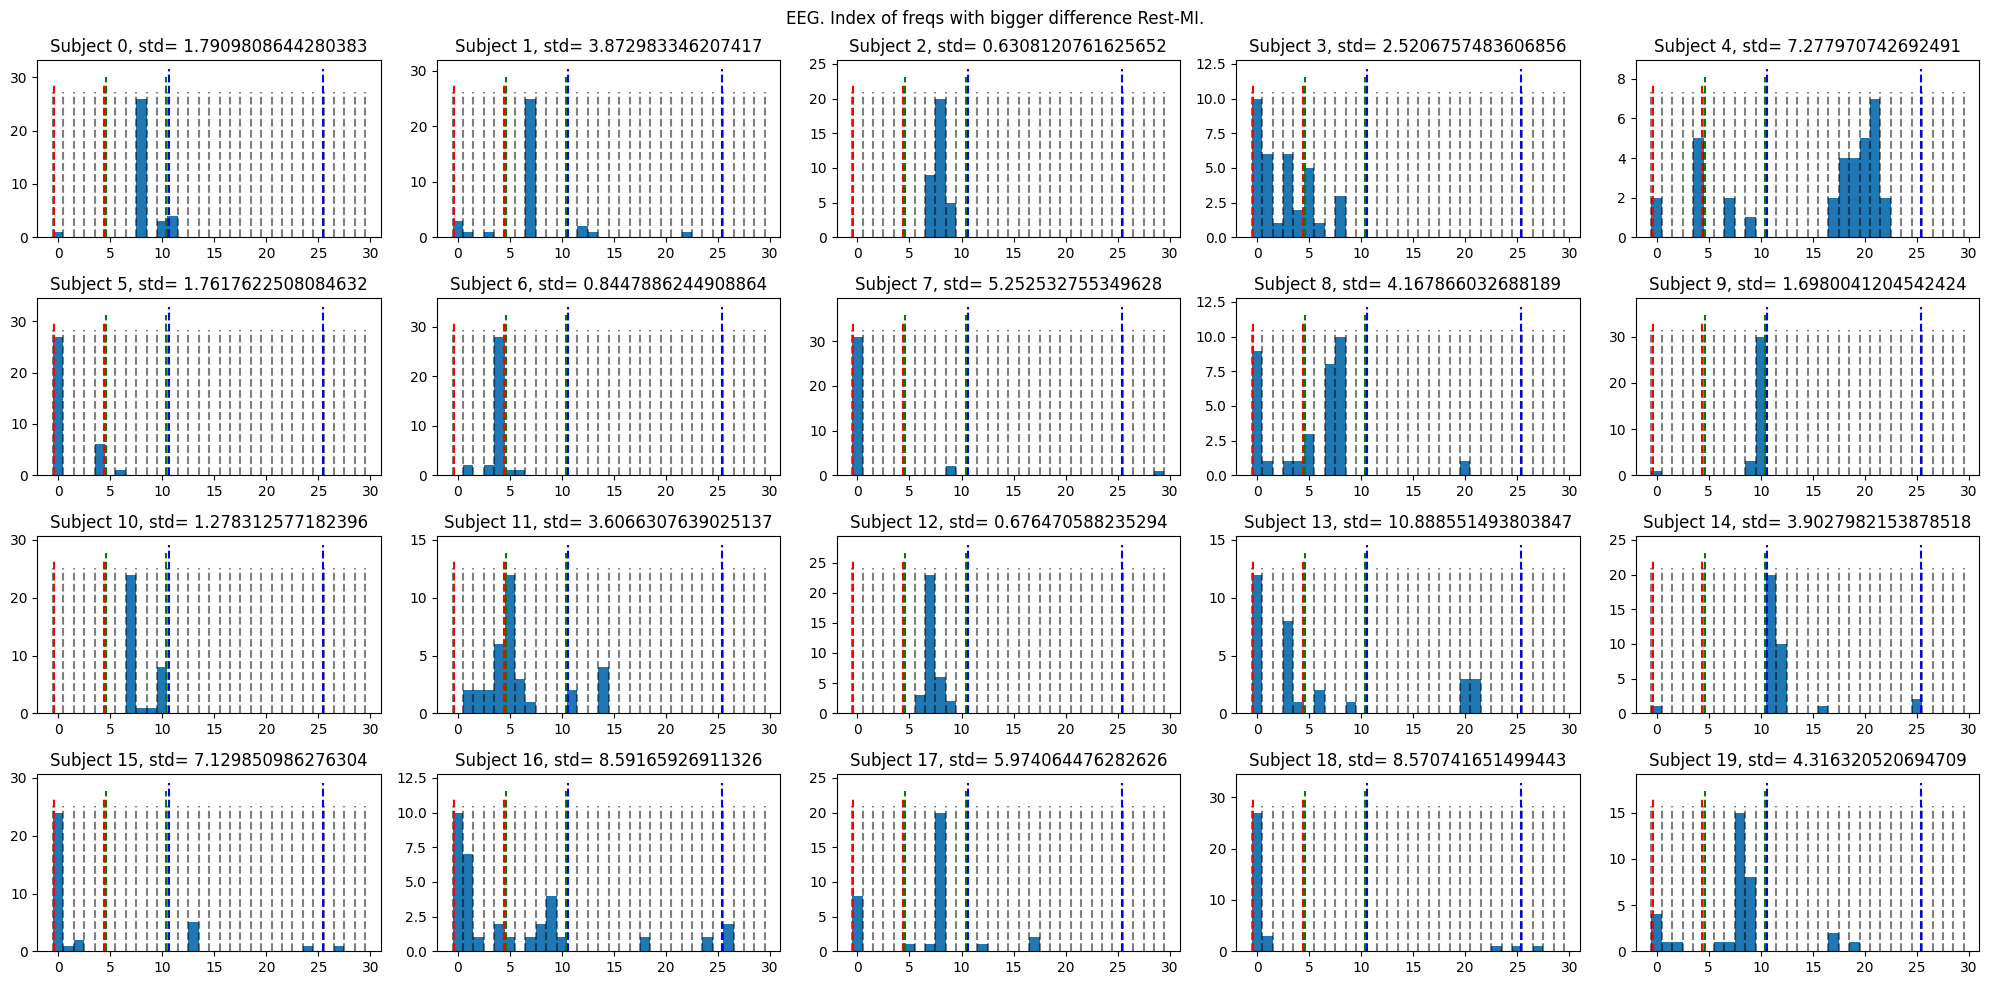

[ 7.5         8.33333333  9.16666667 10.         10.83333333 11.66666667
 12.5       ]


In [ ]:
import mne
import numpy as np
import h5py
from mne.time_frequency import psd_array_welch
import matplotlib.pyplot as plt

# My frequency sampling
sfreq = 250

# power spectra with WELCH metod

#(fmin=0, fmax=inf, n_fft=256, 
# n_overlap, n_per_seg, n_fft,
#  window)
nregions = 34 

fmin=3
fmax=30
n_per_seg = 250             # window to do power spectra
n_fft = n_per_seg + 50      # for the FFT I consider a padding of 0 at the edges, of 25 samples per side
n_overlap = n_per_seg//2

stime = 1 * sfreq
etime = 1 * sfreq

kargs = {"sfreq":sfreq, "fmin":fmin, "fmax":fmax,
        "n_per_seg":n_per_seg, "n_fft":n_fft,
        "n_overlap":n_overlap, "verbose":False}

fig, axes = plt.subplots(4, 5, figsize=(20, 10))  
axes = axes.flatten()  
ids_max=[]
for subject_index in range(20):
    data_2_MI = read_subject(data_folder, "EEG", "MI",subject_index)
    data_2_Rest = read_subject(data_folder, "Rest", "MI",subject_index)

    wpsdMI, frequiMI = psd_array_welch(data_2_MI[:,:,stime:-etime], **kargs )
    wpsdRest, frequiRest = psd_array_welch(data_2_Rest[:,:,stime:-etime], **kargs )

    wpsdRest.shape

    # selecting the ROIs where the difference between MI and Rest is max 

    i_freq_max_rest=[] # indici delle frequenze di dove é il massimo
    i_freq_max_diff=[] # .... where i find the max of diff
    max_rest=[]
    max_diff_perc=[] # max of the difference reported in percentage, not the maximum of the percentage difference

    for roi in range(68):
        wpsdMI_1ROI =wpsdMI[:,roi,:]
        wpsdRest_1ROI =wpsdRest[:,roi,:]
        wpsd_MI_mean = wpsdMI_1ROI.mean(axis=0)
        wpsd_Rest_mean = wpsdRest_1ROI.mean(axis=0)
        
        max_rest.append(np.max(wpsd_Rest_mean))
        max_diff_perc.append(np.max(wpsd_Rest_mean-wpsd_MI_mean)/max_rest[-1])

        i_freq_max_rest.append(np.argmax(wpsd_Rest_mean))
        i_freq_max_diff.append(np.argmax(wpsd_Rest_mean-wpsd_MI_mean))

    i_freq_max_diff=np.array(i_freq_max_diff)
    np.argsort(max_diff_perc) # from smaller to bigger
    # I choose the nregions where I have the greatest difference between MI and Rest 
    # (but being careful to include the Interesting_regions)
    
    selected_regions = [i for i in Interesting_regions]
    for i in range(68):
        if np.argsort(max_diff_perc)[-i-1] not in selected_regions:
            selected_regions.append(int(np.argsort(max_diff_perc)[-i-1]))
        if len(selected_regions) >= nregions:
            break
    ids_max.append(i_freq_max_diff[selected_regions])        


    ax = axes[subject_index]  # select the subplot for this subject
    ax.hist(i_freq_max_diff[selected_regions], bins=np.arange(31)-0.5)
    ax.vlines([i-0.5 for i in range(31)], *ax.get_ylim(), colors="black", linestyles="--", alpha=0.5)
    min_freqs=[4,8,12]
    max_freqs=[8,12,30]

    start_freq_idx = [np.where(frequiMI>=min_freqs[i])[0][0] for i in range(len(min_freqs))]
    end_freq_idx = [np.where(frequiMI<=max_freqs[i])[0][-1] for i in range(len(max_freqs))]
    for i,color in enumerate(["red","green","blue"]):

        ax.vlines([start_freq_idx[i]-0.4, end_freq_idx[i]+0.4], *ax.get_ylim(), colors=color, linestyles="--")

    std_=np.array(i_freq_max_diff[selected_regions]).std()
    ax.set_title(f"Subject {subject_index}, std= {std_}")
    
plt.suptitle("EEG. Index of freqs with bigger difference Rest-MI.")
plt.tight_layout()
plt.show()

print(frequiMI[[4,5,6,7,8,9,10]])

### Frequencies personalized

In [1]:
freq_personalized = {"subject_0":[9,14.5],
                     "subject_1":[8,12],
                     "subject_2":[8,13.5],
                     "subject_3":[4,9.5],
                     "subject_4":[18,23.5],
                     "subject_5":[4,9.5],
                     "subject_6":[4,9.5],
                     "subject_7":[4,9.5],
                     "subject_8":[4,12],
                     "subject_9":[9.5,15.5],
                     "subject_10":[9,14.5],
                     "subject_11":[4,10.5],
                     "subject_12":[8,13.5],
                     "subject_13":[4,10.],
                     "subject_14":[12,18],
                     "subject_15":[4,8],
                     "subject_16":[4,13],
                     "subject_17":[4,12],
                     "subject_18":[4,9.5],
                     "subject_19":[4,12.5],
}

subject_0 trial_78 has wrong shape ((2,))
subject_0 trial_79 has wrong shape ((2,))
subject_0 trial_80 has wrong shape ((2,))
subject_0 trial_81 has wrong shape ((2,))
subject_0 trial_82 has wrong shape ((2,))
subject_0 trial_83 has wrong shape ((2,))
subject_0 trial_84 has wrong shape ((2,))
subject_0 trial_85 has wrong shape ((2,))
subject_0 trial_86 has wrong shape ((2,))
subject_0 trial_87 has wrong shape ((2,))
subject_0 trial_88 has wrong shape ((2,))
subject_0 trial_89 has wrong shape ((2,))
subject_0 trial_90 has wrong shape ((2,))
subject_0 trial_91 has wrong shape ((2,))
subject_0 trial_92 has wrong shape ((2,))
subject_0 trial_93 has wrong shape ((2,))
subject_0 trial_94 has wrong shape ((2,))
subject_0 trial_95 has wrong shape ((2,))
subject_0 trial_78 has wrong shape ((2,))
subject_0 trial_79 has wrong shape ((2,))
subject_0 trial_80 has wrong shape ((2,))
subject_0 trial_81 has wrong shape ((2,))
subject_0 trial_82 has wrong shape ((2,))
subject_0 trial_83 has wrong shape

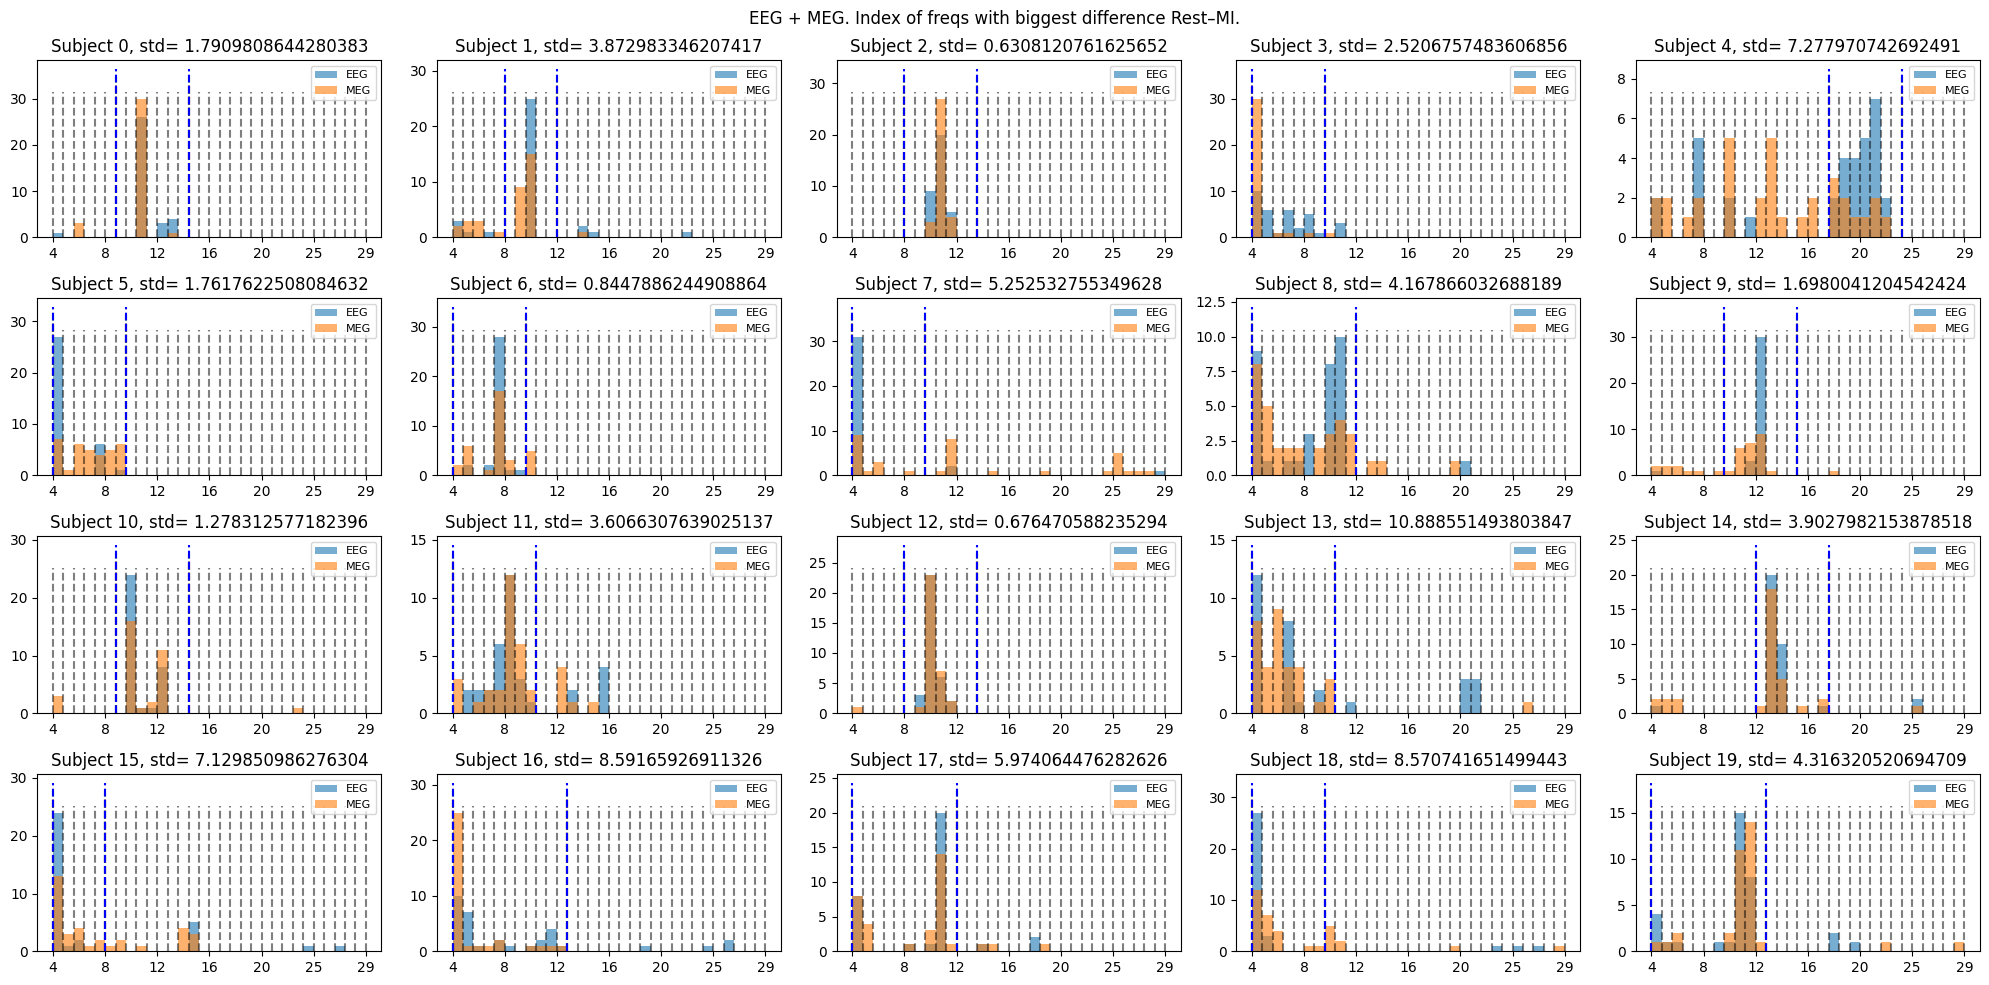

In [ ]:
import mne
import numpy as np
import h5py
from mne.time_frequency import psd_array_welch
import matplotlib.pyplot as plt

Interesting_regions = [4, 5, 32, 33, 44, 45, 48, 49]

Good_subjects = [0, 2, 5, 9, 12, 14]
Ok_subjects = [1, 3, 4, 6, 11, 13, 19]
Other_subjects = [i for i in range(20) if i not in Ok_subjects and i not in Good_subjects]

Subjects_dict = {"Good_subjects": Good_subjects,
                 "Ok_subjects": Ok_subjects,
                 "Other_subjects": Other_subjects}

data_folder="../Data/"

from BCI_Library import read_subject, plot_brain, train_models, extract_features_more_bands, saveresults_pickle

# My frequency sampling
sfreq = 250

# Welch parameters
nregions = 34
fmin = 3
fmax = 30
n_per_seg = 250
n_fft = n_per_seg + 50
n_overlap = n_per_seg // 2

stime = 1 * sfreq
etime = 1 * sfreq

kargs = {
    "sfreq": sfreq,
    "fmin": fmin,
    "fmax": fmax,
    "n_per_seg": n_per_seg,
    "n_fft": n_fft,
    "n_overlap": n_overlap,
    "verbose": False
}

fig, axes = plt.subplots(4, 5, figsize=(20, 10))
axes = axes.flatten()

ids_max = []

for subject_index in range(20):

    # ---- Load EEG ----
    data_2_MI = read_subject(data_folder, "EEG", "MI", subject_index)
    data_2_Rest = read_subject(data_folder, "EEG", "Baseline", subject_index)

    # ---- Load MEG ----
    data_2_MI_MEG = read_subject(data_folder, "MEG", "MI", subject_index)
    data_2_Rest_MEG = read_subject(data_folder, "MEG", "Baseline", subject_index)

    # ---- EEG PSD ----
    wpsdMI, frequiMI = psd_array_welch(data_2_MI[:, :, stime:-etime], **kargs)
    wpsdRest, _ = psd_array_welch(data_2_Rest[:, :, stime:-etime], **kargs)

    # ---- Select important EEG regions ----
    i_freq_max_rest = []
    i_freq_max_diff = []
    max_diff_perc = []

    for roi in range(68):
        MI_roi = wpsdMI[:, roi, :]
        Rest_roi = wpsdRest[:, roi, :]

        MI_mean = MI_roi.mean(axis=0)
        Rest_mean = Rest_roi.mean(axis=0)

        max_rest_val = np.max(Rest_mean)
        max_diff_perc.append(np.max(Rest_mean - MI_mean) / max_rest_val)

        i_freq_max_rest.append(np.argmax(Rest_mean))
        i_freq_max_diff.append(np.argmax(Rest_mean - MI_mean))

    i_freq_max_diff = np.array(i_freq_max_diff)

    # Keep EEG-selected regions
    selected_regions = [i for i in Interesting_regions]
    order = np.argsort(max_diff_perc)

    for i in range(68):
        idx = int(order[-i-1])
        if idx not in selected_regions:
            selected_regions.append(idx)
        if len(selected_regions) >= nregions:
            break

    ids_max.append(i_freq_max_diff[selected_regions])

    eeg_freq_idx = i_freq_max_diff[selected_regions]

    # ---- MEG PSD ----
    wpsdMI_MEG, _ = psd_array_welch(data_2_MI_MEG[:, :, stime:-etime], **kargs)
    wpsdRest_MEG, _ = psd_array_welch(data_2_Rest_MEG[:, :, stime:-etime], **kargs)

    i_freq_max_diff_meg = []
    max_diff_perc_meg = []

    for roi in range(68):
        MI_roi = wpsdMI_MEG[:, roi, :]
        Rest_roi = wpsdRest_MEG[:, roi, :]

        MI_mean = MI_roi.mean(axis=0)
        Rest_mean = Rest_roi.mean(axis=0)

        max_rest_val = np.max(Rest_mean)
        max_diff_perc_meg.append(np.max(Rest_mean - MI_mean) / max_rest_val)

        i_freq_max_diff_meg.append(np.argmax(Rest_mean - MI_mean))

    i_freq_max_diff_meg = np.array(i_freq_max_diff_meg)

    meg_freq_idx = i_freq_max_diff_meg[selected_regions]

    # ---- PLOT ----
    ax = axes[subject_index]

    # EEG histogram
    ax.hist(eeg_freq_idx, bins=np.arange(31), alpha=0.6, label="EEG")

    # MEG histogram
    ax.hist(meg_freq_idx, bins=np.arange(31), alpha=0.6, label="MEG")

    # Vertical guidelines
    ax.vlines(np.arange(31), *ax.get_ylim(), colors="black", linestyles="--", alpha=0.5)

    # Bands markers
    min_freqs = [4, 8, 13]
    max_freqs = [8, 13, 25]

    start_freq_idx = np.where(frequiMI>=freq_personalized[f"subject_{subject_index}"][0])[0][0]
    end_freq_idx = np.where(frequiMI<=freq_personalized[f"subject_{subject_index}"][-1])[0][-1]


    for i, color in enumerate(["red", "green", "blue"]):
        ax.vlines([start_freq_idx, end_freq_idx + 1],
                  *ax.get_ylim(), colors=color, linestyles="--")

    std_ = np.array(eeg_freq_idx).std()
    ax.set_title(f"Subject {subject_index}, std= {std_}")

    # X ticks
    positions = [0, 5, 10, 15, 20, 25, 30]
    ax.set_xticks(positions)
    ax.set_xticklabels([str(int(f)) for f in frequiMI[positions]])

    ax.legend(fontsize=8)

plt.suptitle("EEG + MEG. Index of freqs with biggest difference Rest-MI.")
plt.tight_layout()
plt.show()


# Verify amplitude of signals - across regions - across subjects

How to normalize the amplitude for deep learning?? <br>
For agnostic autoencoders, can concatenate info of region to hidden layer?? (paper adversarial autoencoders) <br>
Mhhhh... how can this info be useful in classification???

In [1]:
import sys
import os
import numpy as np
import scipy.signal as sc_sig
import matplotlib.pyplot as plt


data_folder="../Data/"

def freq_filter(signal,sf,freqs,type_filter="bandpass", order_filter=2):
    """ 
    sf: sampling rate of the input waveform
    freqs: list of frequences (e.g. 2 for bandpass), or single float (e.g. for highpass)
        sf sampling frequence  """
    # type_filter: ‘lowpass’, ‘highpass’, ‘bandpass’, ‘bandstop’

    freqs=np.array(freqs)
    filt_b1,filt_a1=sc_sig.butter(order_filter,freqs/(sf/2),btype=type_filter)
    filtered_sig=sc_sig.filtfilt(filt_b1,filt_a1,sc_sig.detrend(signal)) # both detrend and filtfilt have axis = -1 by default OK!
    return filtered_sig

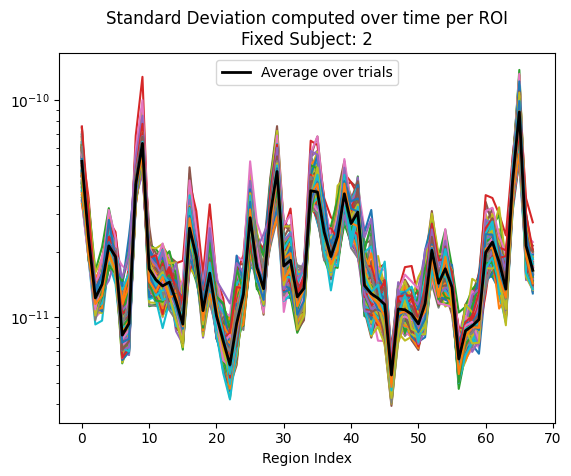

In [4]:
subject = 2
DataType = "EEG"
data_2_Rest = read_subject(data_folder, "MEG", "Baseline",subject)
data_2_MI = read_subject(data_folder, "MEG", "MI",subject)
data = np.concatenate((data_2_Rest, data_2_MI), axis=0)

data = freq_filter(data, sf=250, freqs=[4,45], type_filter="bandpass", order_filter=4)
data = data[:,:,3*250:6*250]


plt.plot(data.std(axis=-1).T)
plt.plot(data.std(axis=-1).mean(axis=0), color="black", linewidth=2, zorder=10,label="Average over trials")
plt.yscale("log")
plt.title(f"Standard Deviation computed over time per ROI\nFixed Subject: {subject}")
plt.xlabel("Region Index")
plt.legend()

In [5]:
subject = 2
DataType = "EEG"
data_2_Rest = read_subject(data_folder, "MEG", "Baseline",subject)
data_2_MI = read_subject(data_folder, "MEG", "MI",subject)
data = np.concatenate((data_2_Rest, data_2_MI), axis=0)

data = freq_filter(data, sf=250, freqs=[4,45], type_filter="bandpass", order_filter=4)
data = data[:,:,3*250:6*250]

In [6]:
data[:,:,1:1+5].shape

(192, 68, 5)

Text(0.5, 0, 'Region Index')

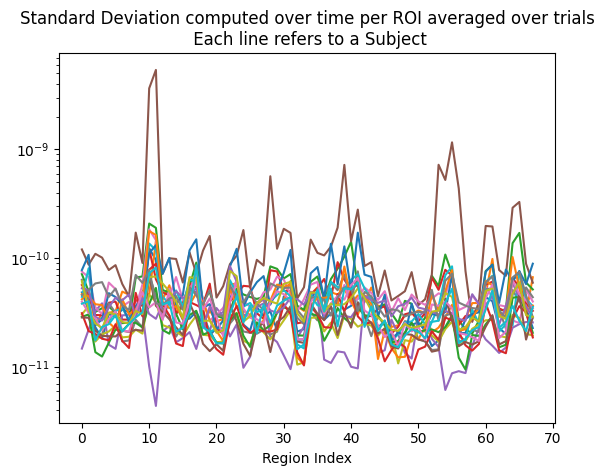

In [7]:
for subject in range(20):
    
    data_2_Rest = read_subject(data_folder, DataType, "Baseline",subject, verbose=False)
    data_2_MI = read_subject(data_folder, DataType, "MI",subject, verbose=False)
    data = np.concatenate((data_2_Rest, data_2_MI), axis=0)

    data = freq_filter(data, sf=250, freqs=[4,45], type_filter="bandpass", order_filter=4)
    data = data[:,:,3*250:6*250]

    plt.plot(data.std(axis=-1).mean(axis=0))

plt.yscale("log")
plt.title(f"Standard Deviation computed over time per ROI averaged over trials\n Each line refers to a Subject")
plt.xlabel("Region Index")

# Test